<a href="https://colab.research.google.com/github/2403a54098-boop/ML-LAB/blob/main/10labipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [16]:
import pandas as pd

In [17]:
df=pd.read_csv('/content/penguins.csv')

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score

In [19]:
for col in df.select_dtypes(include=np.number).columns:
  df[col]=df[col].fillna(df[col].median())

  for col in df.select_dtypes(include='object').columns:
    df[col]=df[col].fillna(df[col].mode()[0])

In [20]:
le_dict={}
for col in df.select_dtypes(include='object').columns:
  le=LabelEncoder()
  df[col]=le.fit_transform(df[col])


In [21]:
x=df.drop('sex',axis=1)
y=df['sex']

In [22]:
scaler=StandardScaler()
x_scaled=scaler.fit_transform(x)

In [23]:
pca=PCA()
param_grid={'n_components': list(range(1,x.shape[1]+1))}
grid_pca=GridSearchCV(pca,param_grid,cv=10)
grid_pca.fit(x_scaled)
best_n=grid_pca.best_params_['n_components']
print('best number of components:',best_n)

best number of components: 1


In [24]:
pca=PCA(n_components=best_n)
x_pca=pca.fit_transform(x_scaled)
x_pca

array([[-1.27063054],
       [-0.85787006],
       [-1.37374369],
       [-0.10711869],
       [-1.91854976],
       [-1.81176492],
       [-1.16560252],
       [-0.73193499],
       [-1.86736378],
       [-0.45639863],
       [-1.3685633 ],
       [-1.0934239 ],
       [-1.23039748],
       [-1.91487355],
       [-1.85262456],
       [-1.34575578],
       [-1.63210845],
       [-0.80641034],
       [-2.03515495],
       [-0.88634994],
       [-1.59223232],
       [-1.54029319],
       [-1.69208328],
       [-1.04958491],
       [-0.88136844],
       [-1.67933132],
       [-1.25063302],
       [-1.36898341],
       [-1.86195087],
       [-1.01104457],
       [-1.13011724],
       [-1.19619797],
       [-1.36705088],
       [-1.0094026 ],
       [-1.46907941],
       [-1.54035186],
       [-1.46746988],
       [-1.05741493],
       [-1.94755517],
       [-0.56367056],
       [-1.85607046],
       [-0.89211697],
       [-2.0757265 ],
       [-0.466541  ],
       [-1.64688673],
       [-0

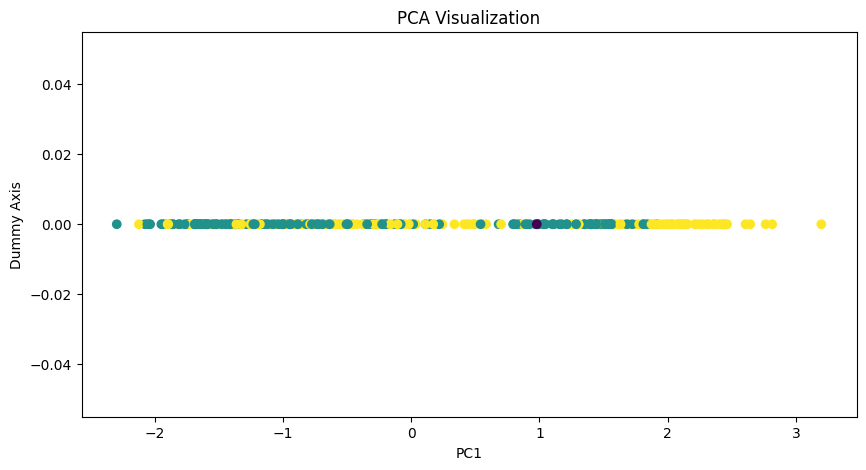

In [25]:
plt.figure(figsize=(10,5))
plt.scatter(x_pca[:,0],np.zeros_like(x_pca[:,0]),c=y)
plt.xlabel("PC1")
plt.ylabel("Dummy Axis")
plt.title("PCA Visualization")
plt.show()

In [26]:
x_train,x_test,y_train,y_test=train_test_split(x_pca,y,test_size=0.2,random_state=42)

In [29]:
dt=DecisionTreeClassifier(random_state=42)
param_grid={
    'criterion':['gini','entropy'],
    'max_depth':[2,3,4,5,6],
    'min_samples_split':[2,3,5,10],
    'min_samples_leaf':[1,2,3,4,]
}
grid_dt=GridSearchCV(dt,param_grid,cv=10)
grid_dt.fit(x_train,y_train)
best_model=grid_dt.best_estimator_
y_pred=best_model.predict(x_test)
print("Best parameters :",grid_dt.best_params_)
print("best criteria:",grid_dt.best_params_['criterion'])
print("Accuracy :",accuracy_score(y_test,y_pred))

Best parameters : {'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 3, 'min_samples_split': 2}
best criteria: entropy
Accuracy : 0.6521739130434783


In [30]:
cm=confusion_matrix(y_test,y_pred)
acc=accuracy_score(y_test,y_pred)
f1=f1_score(y_test,y_pred,average='weighted')
print("Confusion Matrix:")
print(cm)
print("Accuracy:",acc)
print("F1 Score:",f1)

Confusion Matrix:
[[ 0  1  0]
 [ 0 16 14]
 [ 0  9 29]]
Accuracy: 0.6521739130434783
F1 Score: 0.6427932418270582


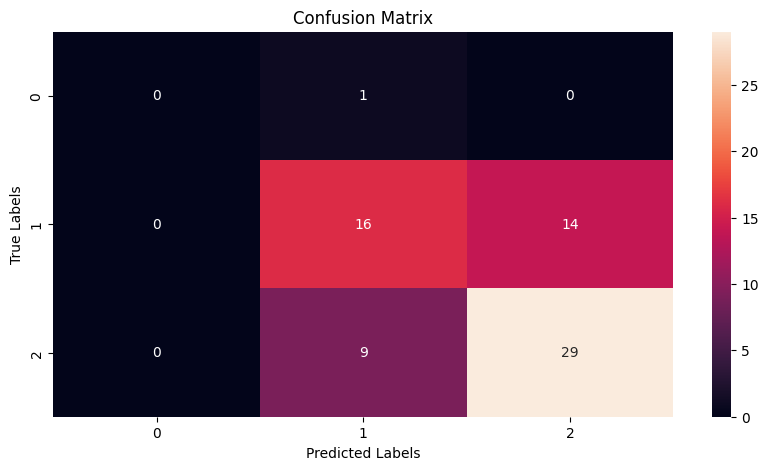

In [32]:
plt.figure(figsize=(10,5))
sns.heatmap(cm,annot=True,fmt='d')
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix")
plt.show()

In [33]:
print(df['sex'].unique)

<bound method Series.unique of 0      2
1      1
2      1
3      2
4      1
      ..
339    2
340    1
341    2
342    1
343    2
Name: sex, Length: 344, dtype: int64>
